In [1]:
from datasets import load_dataset, Dataset, load_from_disk
from tqdm.auto import tqdm
import os
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import AutoModelForSequenceClassification
from transformers import pipeline
import copy
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from rich import print as pprint
import numpy as np
import re
from openai import OpenAI
import numpy as np


/home/takis/anaconda3/envs/unlearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [2]:
num_demonstrations = 8

prompts = []
tasks = []


samples = 100

########################################################### <+1> ###########################################################
# single digit +1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(0, 8)
        p += '%d->%d, ' %(n, n+1)
    prompts.append(p)
tasks.extend(samples*['+1, single digit'])

# double digit +1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(10, 98)
        p += '%d->%d, ' %(n, n+1)
    prompts.append(p)
tasks.extend(samples*['+1, double digit'])

# triple digit +1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(100, 998)
        p += '%d->%d, ' %(n, n+1)
    prompts.append(p)
tasks.extend(samples*['+1, triple digit'])
########################################################### </+1> ###########################################################


########################################################### <-1> ###########################################################
# single digit -1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(1, 9)
        p += '%d->%d, ' %(n, n-1)
    prompts.append(p)
tasks.extend(samples*['-1, single digit'])

# double digit -1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(11, 99)
        p += '%d->%d, ' %(n, n-1)
    prompts.append(p)
tasks.extend(samples*['-1, double digit'])

# triple digit -1
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(101, 999)
        p += '%d->%d, ' %(n, n-1)
    prompts.append(p)
tasks.extend(samples*['-1, triple digit'])
########################################################### </-1> ###########################################################


########################################################### <+2> ###########################################################
# single digit +2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(0, 7)
        p += '%d->%d, ' %(n, n+2)
    prompts.append(p)
tasks.extend(samples*['+2, single digit'])

# double digit +2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(10, 97)
        p += '%d->%d, ' %(n, n+2)
    prompts.append(p)
tasks.extend(samples*['+2, double digit'])

# triple digit +2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(100, 997)
        p += '%d->%d, ' %(n, n+2)
    prompts.append(p)
tasks.extend(samples*['+2, triple digit'])
########################################################### </+2> ###########################################################


########################################################### <-2> ###########################################################
# single digit -2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(2, 9)
        p += '%d->%d, ' %(n, n-2)
    prompts.append(p)
tasks.extend(samples*['-2, single digit'])

# double digit -2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(12, 99)
        p += '%d->%d, ' %(n, n-2)
    prompts.append(p)
tasks.extend(samples*['-2, double digit'])

# triple digit -2
for _ in range(samples):
    p = ''
    for _ in range(num_demonstrations):
        n = np.random.randint(102, 999)
        p += '%d->%d, ' %(n, n-2)
    prompts.append(p)
tasks.extend(samples*['-2, triple digit'])
########################################################### </-2> ###########################################################






In [3]:
len(prompts)

1200

In [4]:
prompts[::30]

['1->2, 3->4, 3->4, 5->6, 4->5, 0->1, 3->4, 7->8, ',
 '2->3, 2->3, 0->1, 2->3, 1->2, 5->6, 4->5, 7->8, ',
 '1->2, 4->5, 2->3, 0->1, 5->6, 5->6, 3->4, 0->1, ',
 '1->2, 2->3, 2->3, 6->7, 7->8, 0->1, 7->8, 0->1, ',
 '14->15, 31->32, 25->26, 11->12, 26->27, 47->48, 49->50, 23->24, ',
 '72->73, 95->96, 31->32, 48->49, 62->63, 20->21, 73->74, 71->72, ',
 '23->24, 72->73, 45->46, 11->12, 46->47, 27->28, 62->63, 11->12, ',
 '867->868, 634->635, 983->984, 949->950, 436->437, 745->746, 470->471, 235->236, ',
 '400->401, 888->889, 130->131, 278->279, 365->366, 892->893, 452->453, 610->611, ',
 '658->659, 214->215, 900->901, 235->236, 458->459, 690->691, 551->552, 633->634, ',
 '6->5, 8->7, 8->7, 8->7, 8->7, 5->4, 1->0, 3->2, ',
 '2->1, 2->1, 7->6, 7->6, 4->3, 3->2, 5->4, 2->1, ',
 '7->6, 6->5, 2->1, 4->3, 1->0, 2->1, 2->1, 1->0, ',
 '2->1, 6->5, 8->7, 5->4, 5->4, 5->4, 2->1, 6->5, ',
 '89->88, 68->67, 25->24, 88->87, 45->44, 29->28, 76->75, 95->94, ',
 '84->83, 71->70, 97->96, 68->67, 85->84, 11-

# Model

In [5]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = '7'
print (torch.cuda.device_count())

device = "cuda" if torch.cuda.is_available() else "cpu"

1


In [6]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models')
model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

# tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-14B-Instruct", cache_dir='/data/takis/models')
# model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-14B-Instruct", cache_dir='/data/takis/models', torch_dtype=torch.bfloat16).to(device)

model = model.eval()

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00,  6.83it/s]


# Hidden states

In [7]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        if (name in activations):
            activations[name].append(output[0])
        else:
            activations[name] = [output[0]]
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    hooks.append(layer.self_attn.register_forward_hook(get_activation(i)))

In [8]:
hidden_states = []

pbar = tqdm(enumerate(prompts), total=len(prompts))
for i, p in pbar:

    pbar.set_description('cur prompt length (chars): %d' %(len(p)))
    
    with torch.inference_mode():
        with torch.no_grad():
            inputs = tokenizer(p, return_tensors="pt").input_ids
            outputs = model.forward(inputs.to(device))
        
    for k in activations.keys():
        activations[k] = torch.cat(activations[k], dim=1).detach().cpu()
        activations[k] =  torch.mean(activations[k], dim=-2)


    hidden_states.append(copy.deepcopy(activations))
    activations = {}

cur prompt length (chars): 80: 100%|██████████| 1200/1200 [00:32<00:00, 37.39it/s]


## t-sne

In [9]:
from matplotlib import rcParams


rcParams['font.family'] = 'serif'
rcParams['text.usetex'] = True

rcParams['axes.grid'] = False
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.9

rcParams['axes.facecolor'] = 'white'
# rcParams['axes.facecolor'] = '#f8f9fa'
# rcParams['axes.linewidth'] = 2
# rcParams['axes.axisbelow'] = True
rcParams['axes.labelsize'] = 35
rcParams['axes.titlesize'] = 30

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.spines.bottom'] = False
rcParams['axes.spines.left'] = False

rcParams['lines.linewidth'] = 4
rcParams['lines.markersize'] = 15

rcParams['legend.fontsize'] = 25
rcParams['xtick.labelsize'] = 25
rcParams['ytick.labelsize'] = 25
rcParams['figure.figsize'] = (4, 3)

In [10]:
target_layers = [i for i in range(len(model.model.layers))]

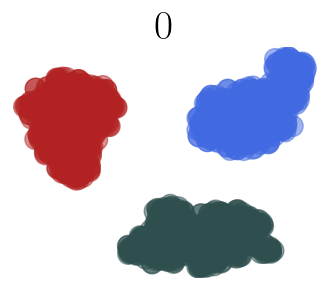

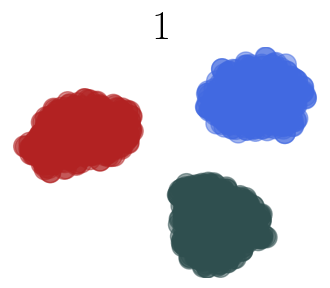

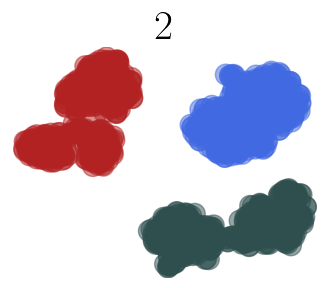

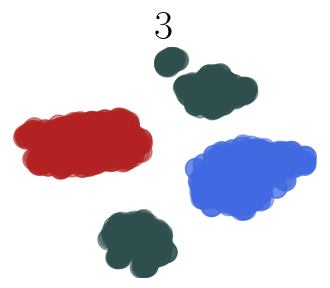

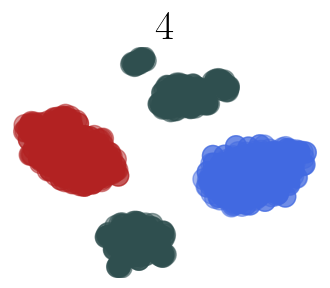

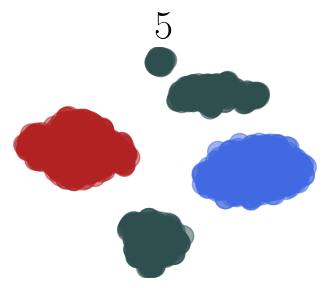

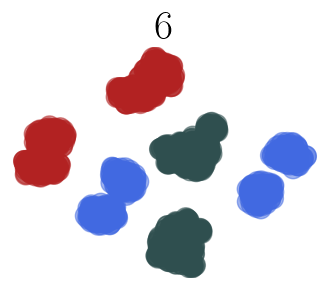

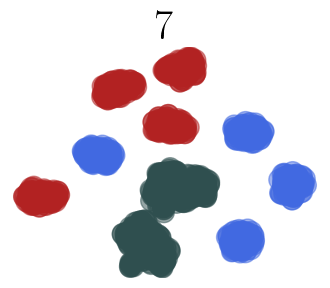

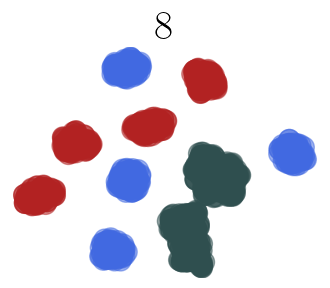

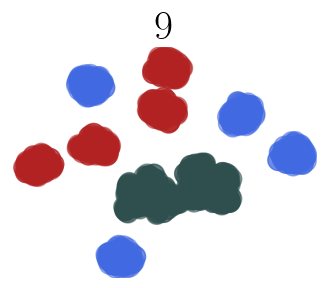

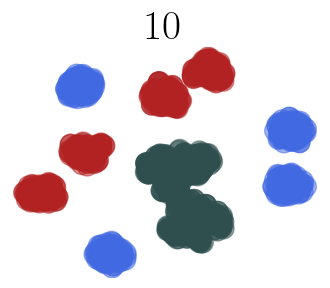

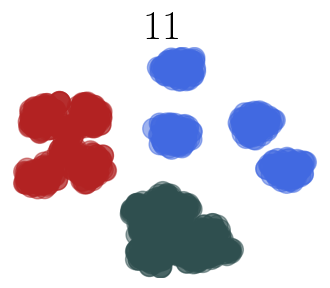

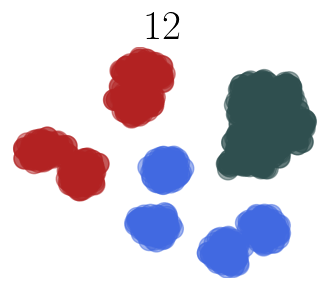

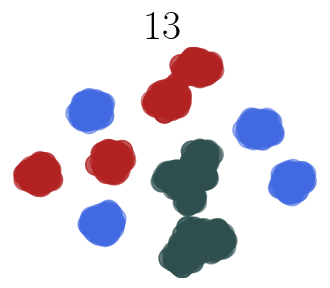

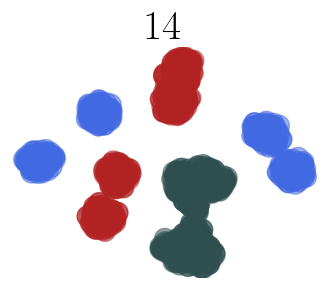

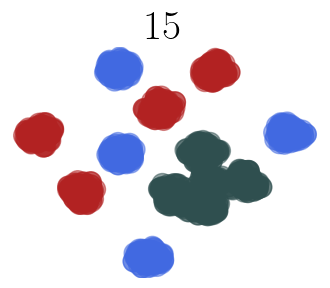

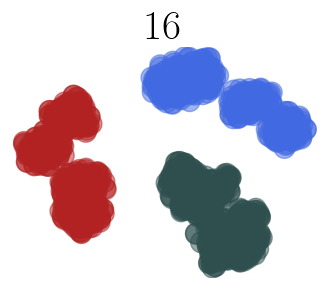

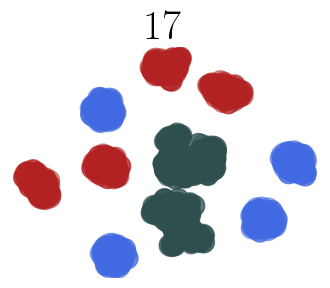

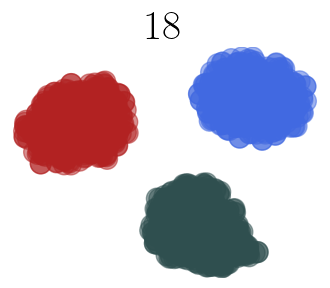

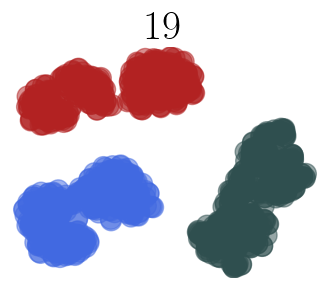

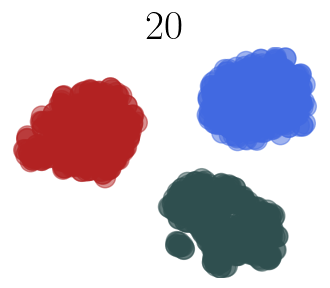

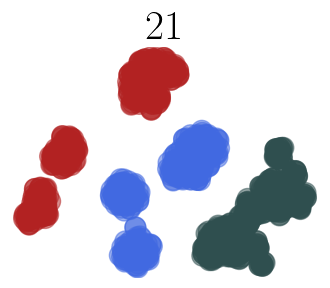

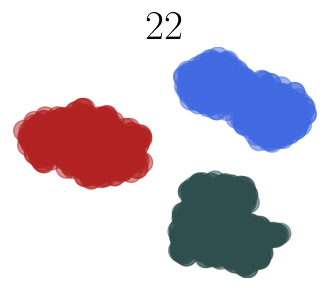

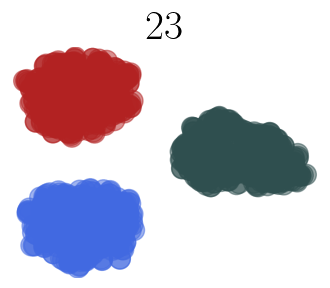

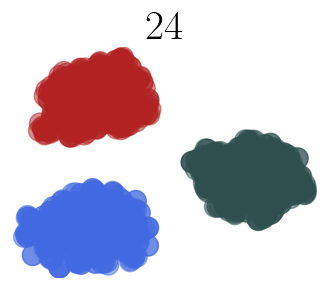

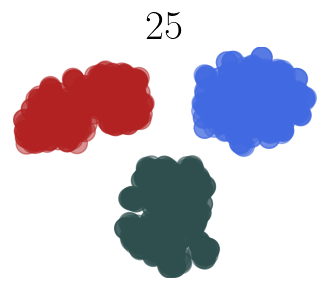

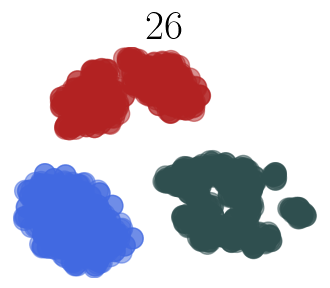

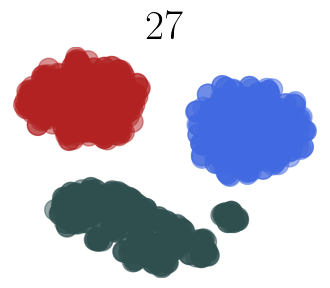

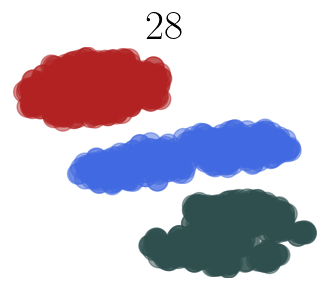

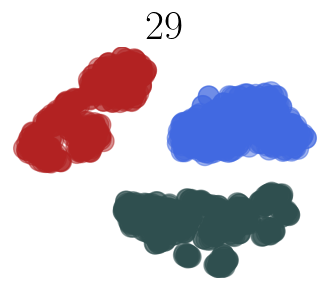

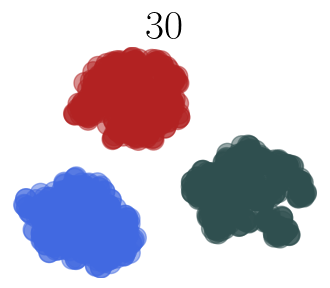

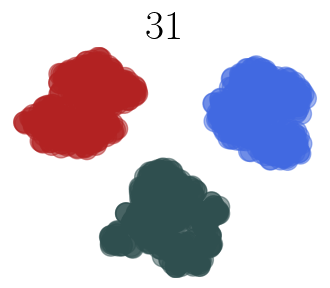

In [11]:
colors = []
cur_states = []

for i in range(len(prompts)):
    if (tasks[i] == '+1, single digit'):
        colors.append('darkslategray')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '+1, double digit'):
        colors.append('firebrick')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '+1, triple digit'):
        colors.append('royalblue')
        cur_states.append(hidden_states[i])

    if (tasks[i] == '-1, single digit'):
        colors.append('darkslategray')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '-1, double digit'):
        colors.append('firebrick')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '-1, triple digit'):
        colors.append('royalblue')
        cur_states.append(hidden_states[i])

    if (tasks[i] == '+2, single digit'):
        colors.append('darkslategray')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '+2, double digit'):
        colors.append('firebrick')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '+2, triple digit'):
        colors.append('royalblue')
        cur_states.append(hidden_states[i])

    if (tasks[i] == '-2, single digit'):
        colors.append('darkslategray')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '-2, double digit'):
        colors.append('firebrick')
        cur_states.append(hidden_states[i])
    if (tasks[i] == '-2, triple digit'):
        colors.append('royalblue')
        cur_states.append(hidden_states[i])


for target_layer in target_layers:

    cur_concepts = []
    for h in cur_states:
        cur_concepts.append(h[target_layer])
    cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

    cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

    plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
    plt.xticks([])
    plt.yticks([])
    plt.title(target_layer)
    plt.show()

In [12]:
# colors = []
# cur_states = []


# for i in range(len(prompts)):
#     # if (tasks[i] == '+1, single digit'):
#     #     colors.append('slateblue')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '+1, double digit'):
#         colors.append('darkorange')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '+1, triple digit'):
#     #     colors.append('black')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '-1, single digit'):
#     #     colors.append('chocolate')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '-1, double digit'):
#         colors.append('darkmagenta')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-1, triple digit'):
#     #     colors.append('red')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '+2, single digit'):
#     #     colors.append('maroon')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '+2, double digit'):
#         colors.append('darkorange')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '+2, triple digit'):
#     #     colors.append('blue')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '-2, single digit'):
#     #     colors.append('darkgreen')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '-2, double digit'):
#         colors.append('darkmagenta')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-2, triple digit'):
#     #     colors.append('gray')
#     #     cur_states.append(hidden_states[i])


# for target_layer in target_layers:

#     cur_concepts = []
#     for h in cur_states:
#         cur_concepts.append(h[target_layer])
#     cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

#     cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=20, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

#     plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
#     plt.xticks([])
#     plt.yticks([])
#     plt.title(target_layer)
#     plt.show()

In [13]:
# colors = []
# cur_states = []

# for i in range(len(prompts)):
#     # if (tasks[i] == '+1, single digit'):
#     #     colors.append('slateblue')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '+1, double digit'):
#         colors.append('darkgoldenrod')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '+1, triple digit'):
#     #     colors.append('black')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '-1, single digit'):
#     #     colors.append('chocolate')
#     #     cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-1, double digit'):
#     #     colors.append('darkmagenta')
#     #     cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-1, triple digit'):
#     #     colors.append('red')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '+2, single digit'):
#     #     colors.append('maroon')
#     #     cur_states.append(hidden_states[i])
#     if (tasks[i] == '+2, double digit'):
#         colors.append('navy')
#         cur_states.append(hidden_states[i])
#     # if (tasks[i] == '+2, triple digit'):
#     #     colors.append('blue')
#     #     cur_states.append(hidden_states[i])

#     # if (tasks[i] == '-2, single digit'):
#     #     colors.append('darkgreen')
#     #     cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-2, double digit'):
#     #     colors.append('darkorange')
#     #     cur_states.append(hidden_states[i])
#     # if (tasks[i] == '-2, triple digit'):
#     #     colors.append('gray')
#     #     cur_states.append(hidden_states[i])


# for target_layer in target_layers:

#     cur_concepts = []
#     for h in cur_states:
#         cur_concepts.append(h[target_layer])
#     cur_concepts = torch.stack(cur_concepts, dim=0).squeeze()

#     cur_concepts_emb = TSNE(n_components=2, metric='cosine', learning_rate='auto', init='random', perplexity=40, random_state=0).fit_transform(cur_concepts.detach().cpu().float().numpy())

#     plt.scatter(cur_concepts_emb[:, 0], cur_concepts_emb[:, 1], c=colors, alpha=0.5)
#     plt.xticks([])
#     plt.yticks([])
#     plt.title(target_layer)
#     plt.show()

# Steering

In [35]:
for hook in hooks:
    hook.remove()

In [36]:
strength = 1
target_layer = 15

def change_behavior(target_layer):
    def hook(model, input, output):
        # output = ((1-strength)*output[0] + strength*prototypes[sentiment][target_layer].to(device), *output[1:])
        output = (output[0] + strength*prototype[target_layer].to(device), *output[1:])
        return output
    return hook


hooks = []
for i, layer in enumerate(model.model.layers):
    if (i == target_layer):
        hooks.append(layer.self_attn.register_forward_hook(change_behavior(i)))

## -2 all

In [44]:
prototype = {}

for l in target_layers:
    prototype[l] = []
    for i in range(len(prompts)):
        if (tasks[i][:2] == '-1'):
            prototype[l].append(hidden_states[i][l])

    prototype[l] = torch.vstack(prototype[l])

    # print (prototype[l].shape)
    prototype[l] = prototype[l].mean(0)


In [45]:


for strength in range(4, 8):

    correct = []

    for i in tqdm(range(0, 100)):
        prompt = f'{i}->'
        expected = f'{i}->{i-1}'
    

        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=10, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        # output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
        output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        if (expected in output_text):
            correct.append(1)
        else:
            correct.append(0)
            
        activations = {}

    print (strength, np.sum(correct)/len(correct))

100%|██████████| 100/100 [00:18<00:00,  5.44it/s]


4 0.78


100%|██████████| 100/100 [00:18<00:00,  5.43it/s]


5 0.96


100%|██████████| 100/100 [00:18<00:00,  5.42it/s]


6 0.98


100%|██████████| 100/100 [00:18<00:00,  5.46it/s]

7 0.95


In [46]:
for strength in range(4, 8):

    correct = []

    for i in tqdm(range(100, 1000)):
        prompt = f'{i}->'
        expected = f'{i}->{i-1}'
    

        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=10, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        # output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
        output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        if (expected in output_text):
            correct.append(1)
        else:
            correct.append(0)
            
        activations = {}

    print (strength, np.sum(correct)/len(correct))

100%|██████████| 900/900 [02:45<00:00,  5.45it/s]


4 0.39222222222222225


100%|██████████| 900/900 [02:45<00:00,  5.45it/s]


5 0.5333333333333333


100%|██████████| 900/900 [02:44<00:00,  5.46it/s]


6 0.58


100%|██████████| 900/900 [02:44<00:00,  5.46it/s]

7 0.5755555555555556


## +2 double

In [62]:
prototype = {}

for l in target_layers:
    prototype[l] = []
    for i in range(len(prompts)):
        if (tasks[i] == '+2, double digit'):
            prototype[l].append(hidden_states[i][l])

    prototype[l] = torch.vstack(prototype[l])

    # print (prototype[l].shape)
    prototype[l] = prototype[l].mean(0)

In [63]:
for strength in range(4, 8):

    correct = []

    for i in tqdm(range(100, 1000)):
        prompt = f'{i}->'
        expected = f'{i}->{i+2}'
    

        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=10, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        # output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
        output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        if (expected in output_text):
            correct.append(1)
        else:
            correct.append(0)
            
        activations = {}

    print (strength, np.sum(correct)/len(correct))

100%|██████████| 900/900 [02:45<00:00,  5.45it/s]


4 0.5533333333333333


100%|██████████| 900/900 [02:44<00:00,  5.45it/s]


5 0.5477777777777778


100%|██████████| 900/900 [02:44<00:00,  5.46it/s]


6 0.4633333333333333


  2%|▏         | 20/900 [00:03<02:43,  5.37it/s]


KeyboardInterrupt: 

## -2 triple

In [58]:
prototype = {}

for l in target_layers:
    prototype[l] = []
    for i in range(len(prompts)):
        if (tasks[i] == '+2, triple digit'):
            prototype[l].append(hidden_states[i][l])

    prototype[l] = torch.vstack(prototype[l])

    # print (prototype[l].shape)
    prototype[l] = prototype[l].mean(0)

In [59]:
for strength in range(4, 8):

    correct = []

    for i in tqdm(range(0, 100)):
        prompt = f'{i}->'
        expected = f'{i}->{i+2}'
    

        inputs = tokenizer(prompt, return_tensors="pt").input_ids
        outputs = model.generate(inputs.to(device), max_new_tokens=10, do_sample=False, top_k=50, top_p=0.95, pad_token_id=tokenizer.eos_token_id).detach().cpu()
        # output_text = tokenizer.batch_decode(outputs[:, inputs.shape[1]:], skip_special_tokens=True)[0]
        output_text = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

        if (expected in output_text):
            correct.append(1)
        else:
            correct.append(0)
            
        activations = {}

    print (strength, np.sum(correct)/len(correct))

100%|██████████| 100/100 [00:18<00:00,  5.43it/s]


4 0.82


100%|██████████| 100/100 [00:18<00:00,  5.45it/s]


5 0.88


100%|██████████| 100/100 [00:18<00:00,  5.45it/s]


6 0.83


100%|██████████| 100/100 [00:18<00:00,  5.45it/s]

7 0.78


In [51]:
1

1